# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "hfc125"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[1.897 1.897 1.897 ... 2.5172222222222222 2.6149999999999998 2.696] [1.897 1.897 1.897 ... 2.525611111111111 2.6149999999999998 2.696] [1.897 1.897 1.897 ... 2.534 2.615 2.696] [1.897 1.897 1.897 ... 3.079 2.8875 2.696] [1.897 1.897 1.897 ... 2.5004444444444447 2.602416666666667 2.696] [1.897 1.897 1.897 ... 2.5088333333333335 2.6108055555555554 2.696]] [[1.962 1.962 1.962 ... 2.525 2.6055 2.6460000000000004] [1.962 1.962 1.962 ... 2.5450000000000004 2.6055 2.646] [1.962 1.962 1.962 ... 2.565 2.6054999999999997 2.6459999999999995] [1.962 1.962 1.962 ... 3.236 2.941 2.646] [1.962 1.962 1.962 ... 2.4850000000000003 2.5755 2.646] [1.962 1.962 1.962 ... 2.505 2.5955000000000004 2.646]] [[1.925 1.925 1.925 ... 2.6060000000000003 2.7215 2.8430000000000004] [1.925 1.925 1.925 ... 2.603 2.7215 2.843] [1.925 1.925 1.925 ... 2.6 2.7215 2.843] [1.925 1.925 1.925 ... 3.049 2.9459999999999997 2.843] [1.925 1.925 1.925 ... 2.612 2.726 2.843] [1.925 1.925 1.925 ... 2.609 2.7230000000000003 2.843]] ... [[43.304 43.304 43.304 ... 49.137 48.823 48.509] [43.304 43.304 43.304 ... 49.137 48.823 48.509] [43.304 43.304 43.304 ... 48.807 48.823 48.509] [43.304 43.304 43.304 ... 49.87233333333334 49.19066666666667 48.509] [43.304 43.304 43.304 ... 49.504666666666665 48.823 48.509] [43.304 43.304 43.304 ... 49.137 48.823 48.509]] [[43.769 43.769 43.769 ... 49.65033333333333 49.467666666666666 49.285] [43.769 43.769 43.769 ... 49.65033333333333 49.46766666666666 49.285] [43.769 43.769 43.769 ... 49.583 49.46766666666666 49.285] [43.769 43.769 43.769 ... 50.290666666666674 49.78783333333334 49.285] [43.769 43.769 43.769 ... 49.9705 49.467666666666666 49.285] [43.769 43.769 43.769 ... 49.65033333333333 49.467666666666666 49.285]] [[43.912 43.912 43.912 ... 50.121 50.080000000000005 50.039] [43.912 43.912 43.912 ... 50.121 50.08 50.039] [43.912 43.912 43.912 ... 50.27366666666667 50.08 50.039] [43.912 43.912 43.912 ... 50.42633333333333 50.23266666666667 50.039] [43.912 43.912 43.912 ... 50.273666666666664 50.08 50.039] [43.912 43.912 43.912 ... 50.120999999999995 50.080000000000005 50.039]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[1.897 1.897 1.897 ... 2.5172222222222222 2.6149999999999998 2.696] [1.897 1.897 1.897 ... 2.525611111111111 2.6149999999999998 2.696] [1.897 1.897 1.897 ... 2.534 2.615 2.696] [1.897 1.897 1.897 ... 3.079 2.8875 2.696] [1.897 1.897 1.897 ... 2.5004444444444447 2.602416666666667 2.696] [1.897 1.897 1.897 ... 2.5088333333333335 2.6108055555555554 2.696]] [[1.962 1.962 1.962 ... 2.525 2.6055 2.6460000000000004] [1.962 1.962 1.962 ... 2.5450000000000004 2.6055 2.646] [1.962 1.962 1.962 ... 2.565 2.6054999999999997 2.6459999999999995] [1.962 1.962 1.962 ... 3.236 2.941 2.646] [1.962 1.962 1.962 ... 2.4850000000000003 2.5755 2.646] [1.962 1.962 1.962 ... 2.505 2.5955000000000004 2.646]] [[1.925 1.925 1.925 ... 2.6060000000000003 2.7215 2.8430000000000004] [1.925 1.925 1.925 ... 2.603 2.7215 2.843] [1.925 1.925 1.925 ... 2.6 2.7215 2.843] [1.925 1.925 1.925 ... 3.049 2.9459999999999997 2.843] [1.925 1.925 1.925 ... 2.612 2.726 2.843] [1.925 1.925 1.925 ... 2.609 2.7230000000000003 2.843]] ... [[43.304 43.304 43.304 ... 49.137 48.823 48.509] [43.304 43.304 43.304 ... 49.137 48.823 48.509] [43.304 43.304 43.304 ... 48.807 48.823 48.509] [43.304 43.304 43.304 ... 49.87233333333334 49.19066666666667 48.509] [43.304 43.304 43.304 ... 49.504666666666665 48.823 48.509] [43.304 43.304 43.304 ... 49.137 48.823 48.509]] [[43.769 43.769 43.769 ... 49.65033333333333 49.467666666666666 49.285] [43.769 43.769 43.769 ... 49.65033333333333 49.46766666666666 49.285] [43.769 43.769 43.769 ... 49.583 49.46766666666666 49.285] [43.769 43.769 43.769 ... 50.290666666666674 49.78783333333334 49.285] [43.769 43.769 43.769 ... 49.9705 49.467666666666666 49.285] [43.769 43.769 43.769 ... 49.65033333333333 49.467666666666666 49.285]] [[43.912 43.912 43.912 ... 50.121 50.080000000000005 50.039] [43.912 43.912 43.912 ... 50.121 50.08 50.039] [43.912 43.912 43.912 ... 50.27366666666667 50.08 50.039] [43.912 43.912 43.912 ... 50.42633333333333 50.23266666666667 50.039] [43.912 43.912 43.912 ... 50.273666666666664 50.08 50.039] [43.912 43.912 43.912 ... 50.120999999999995 50.080000000000005 50.039]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'hfc125' (lon: 6, lat: 12, year: 20, month: 12)> Size: 138kB
<Quantity([[[[ 2.689       2.757       2.7785     ...  3.097       3.119
     3.149     ]
   [ 3.175       3.209       3.284      ...  3.684       3.784
     3.783     ]
   [ 3.795       3.848       3.935      ...  4.4         4.461
     4.43      ]
   ...
   [31.1555     31.51366667 31.84433333 ... 34.15633333 34.385
    34.513     ]
   [34.68       36.448      36.919      ... 39.409      39.762
    40.002     ]
   [45.842      46.15       40.951      ... 43.304      43.769
    43.912     ]]

  [[ 2.689       2.757       2.7785     ...  3.097       3.119
     3.149     ]
   [ 3.175       3.209       3.284      ...  3.684       3.784
     3.783     ]
   [ 3.795       3.848       3.935      ...  4.4         4.461
     4.449     ]
...
   [36.693      37.438      37.0985     ... 39.64736111 40.29511111
    40.71572222]
   [41.2755     42.28233333 42.24333333 ... 44.85066667 45.41866667
    45.52433333]
   [45.93       46.18733333 46.47466667 ... 48.823      49.46766667
    50.08      ]]

  [[ 3.464       3.779       3.7        ...  4.026       3.895
     3.892     ]
   [ 4.216       4.29        4.446      ...  4.941       5.093
     5.031     ]
   [ 5.417       5.191       5.294      ...  5.896       6.135
     6.075     ]
   ...
   [36.8215     37.137      37.448      ... 39.8165     40.3595
    41.06975   ]
   [42.179      42.381      42.251      ... 44.683      45.43
    45.519     ]
   [45.974      46.206      46.436      ... 48.509      49.285
    50.039     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 160B 2004 2005 2006 2007 2008 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] [2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] [2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] ... [3.4595555555555553 3.5840555555555556 3.583166666666667 ... 49.137 49.65033333333333 50.121] [3.5375 3.7057499999999997 3.687 ... 48.823 49.467666666666666 50.080000000000005] [3.464 3.779 3.7 ... 48.509 49.285 50.039]] [[2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] [2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] [2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] ... [3.5352777777777784 3.608277777777778 3.6285833333333333 ... 49.137 49.65033333333333 50.121] [3.5375000000000005 3.70575 3.6870000000000003 ... 48.823 49.46766666666666 50.08] [3.464 3.779 3.7 ... 48.509 49.285 50.039]] [[2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] [2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] [2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] ... [3.6110000000000007 3.6325000000000003 3.674 ... 48.807 49.583 50.27366666666667] [3.5375 3.7057499999999997 3.687 ... 48.823 49.46766666666666 50.08] [3.464 3.7789999999999995 3.7 ... 48.509 49.285 50.039]] [[2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] [2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] [2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] ... [3.711 3.559 3.542 ... 49.87233333333334 50.290666666666674 50.42633333333333] [3.5875 3.669 3.621 ... 49.19066666666667 49.78783333333334 50.23266666666667] [3.464 3.779 3.7 ... 48.509 49.285 50.039]] [[2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] [2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] [2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] ... [3.3081111111111112 3.535611111111111 3.4923333333333337 ... 49.504666666666665 49.9705 50.273666666666664] [3.4239166666666665 3.6694166666666663 3.618875 ... 48.823 49.467666666666666 50.08] [3.464 3.779 3.7 ... 48.509 49.285 50.039]] [[2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] [2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] [2.689 2.7569999999999997 2.7785 ... 43.304 43.769 43.912] ... [3.3838333333333335 3.559833333333333 3.53775 ... 49.137 49.65033333333333 50.120999999999995] [3.499638888888889 3.693638888888889 3.6642916666666667 ... 48.823 49.467666666666666 50.080000000000005] [3.464 3.779 3.7 ... 48.509 49.285 50.039]]]
Units,ppt


### Longitudinal-mean

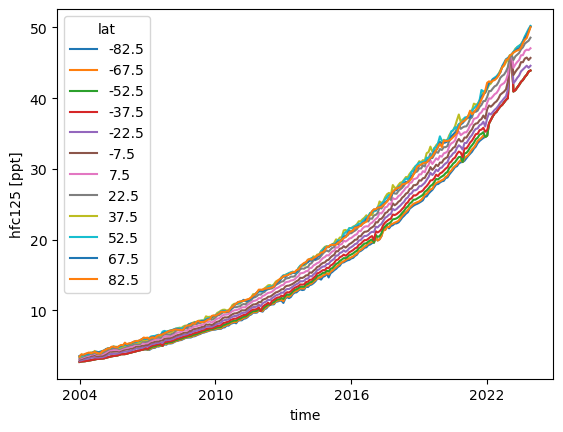

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

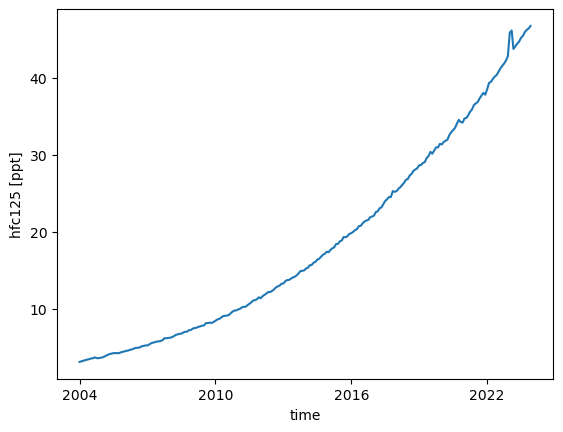

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

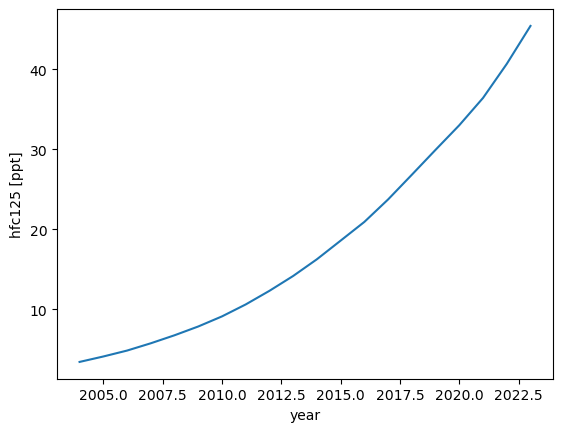

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 3kB
Dimensions:               (lat: 12, eof: 12, year: 20)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 160B 2004 2005 2006 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.4269 ... 0.05329
    principal-components  (year, eof) float64 2kB [] -1.371 ... -9.928e-16

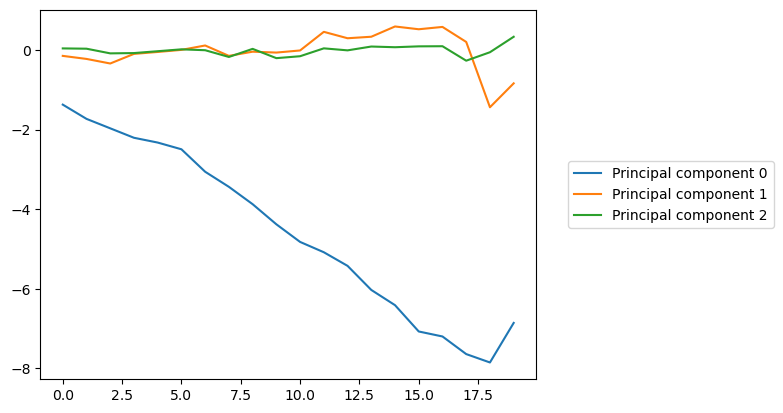

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

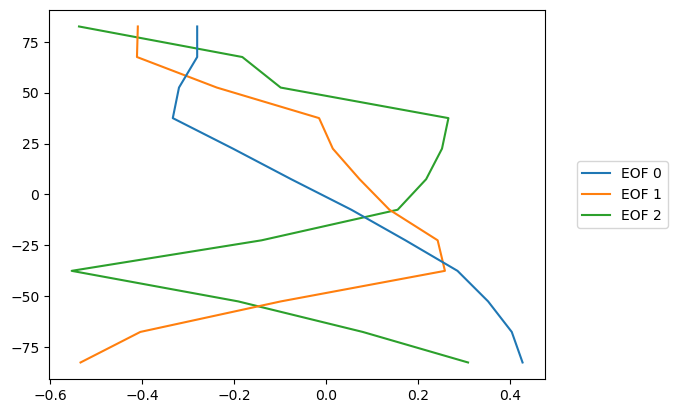

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

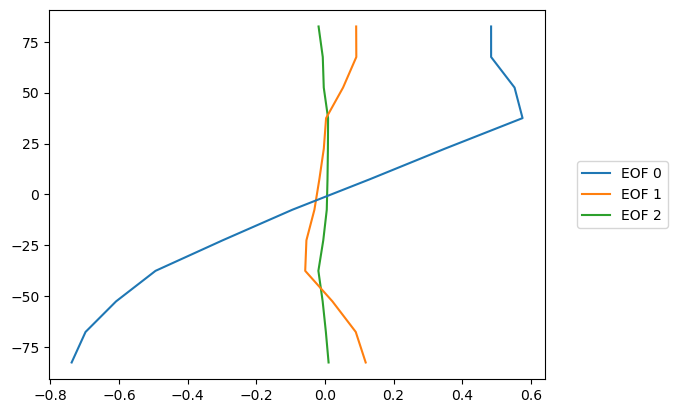

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.42692608156216194] [0.40348301613233933] [0.35207082516946275] [0.2855560430977262] [0.17235625678656974] [0.05494682337719199] [-0.07586703691274332] [-0.2022990203440026] [-0.3331063285985232] [-0.31962690750485545] [-0.2801120348147049] [-0.2800874597572463]]
Units,ppt
Magnitude,[[-1.3710821934573918] [-1.729205216399428] [-1.966729861719875] [-2.204364714704712] [-2.3244840523583514] [-2.4934894329922623] [-3.058023828414034] [-3.4372995944444047] [-3.873267058673456] [-4.378648182522422] [-4.821761407478649] [-5.081119510359022] [-5.423394783326795] [-6.028393271232784] [-6.411355330375513] [-7.0726817182927615] [-7.198164550511677] [-7.640671990820314] [-7.851633498096175] [-6.857523892240453]]
Units,dimensionless


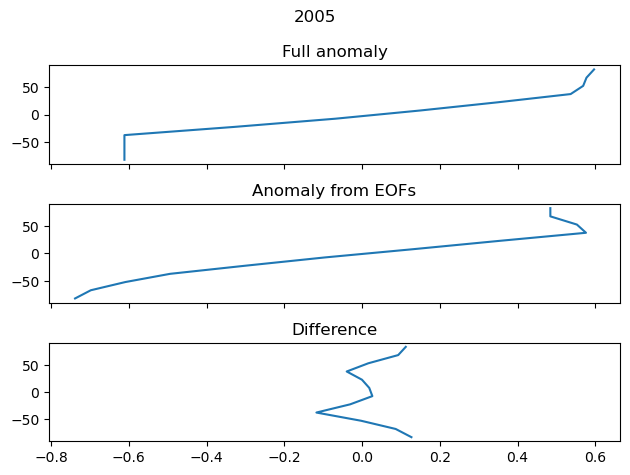

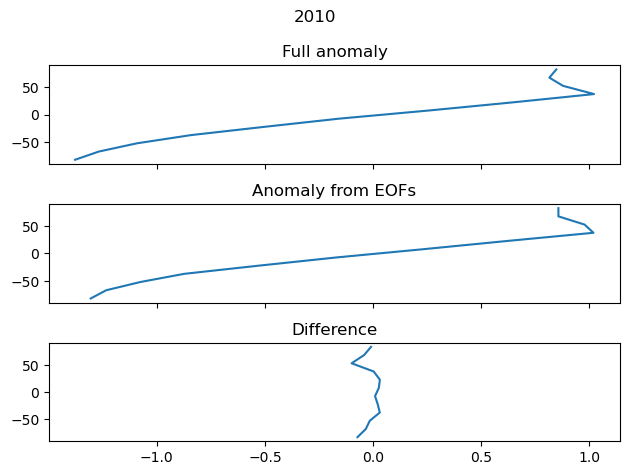

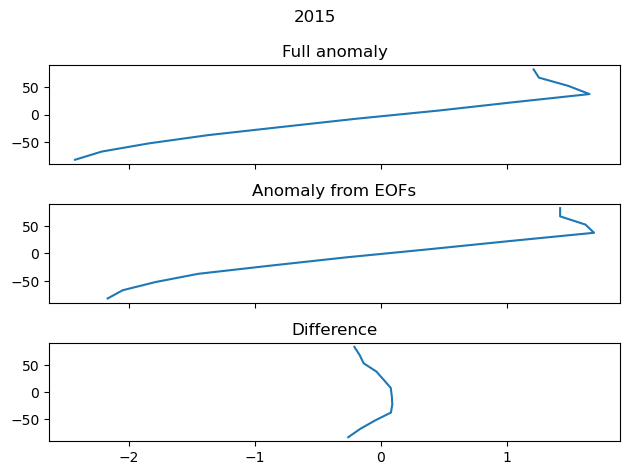

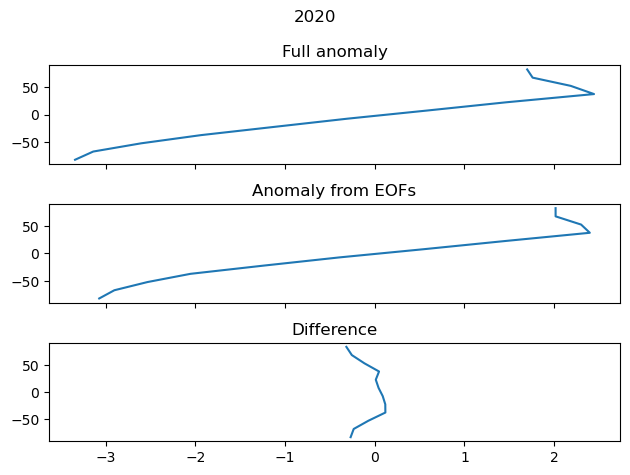

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/240 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 240/240 [00:00<00:00, 17237.46it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/240 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/240 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 240/240 [00:00<00:00, 20005.03it/s]

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/240 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 240/240 [00:00<00:00, 19847.65it/s]

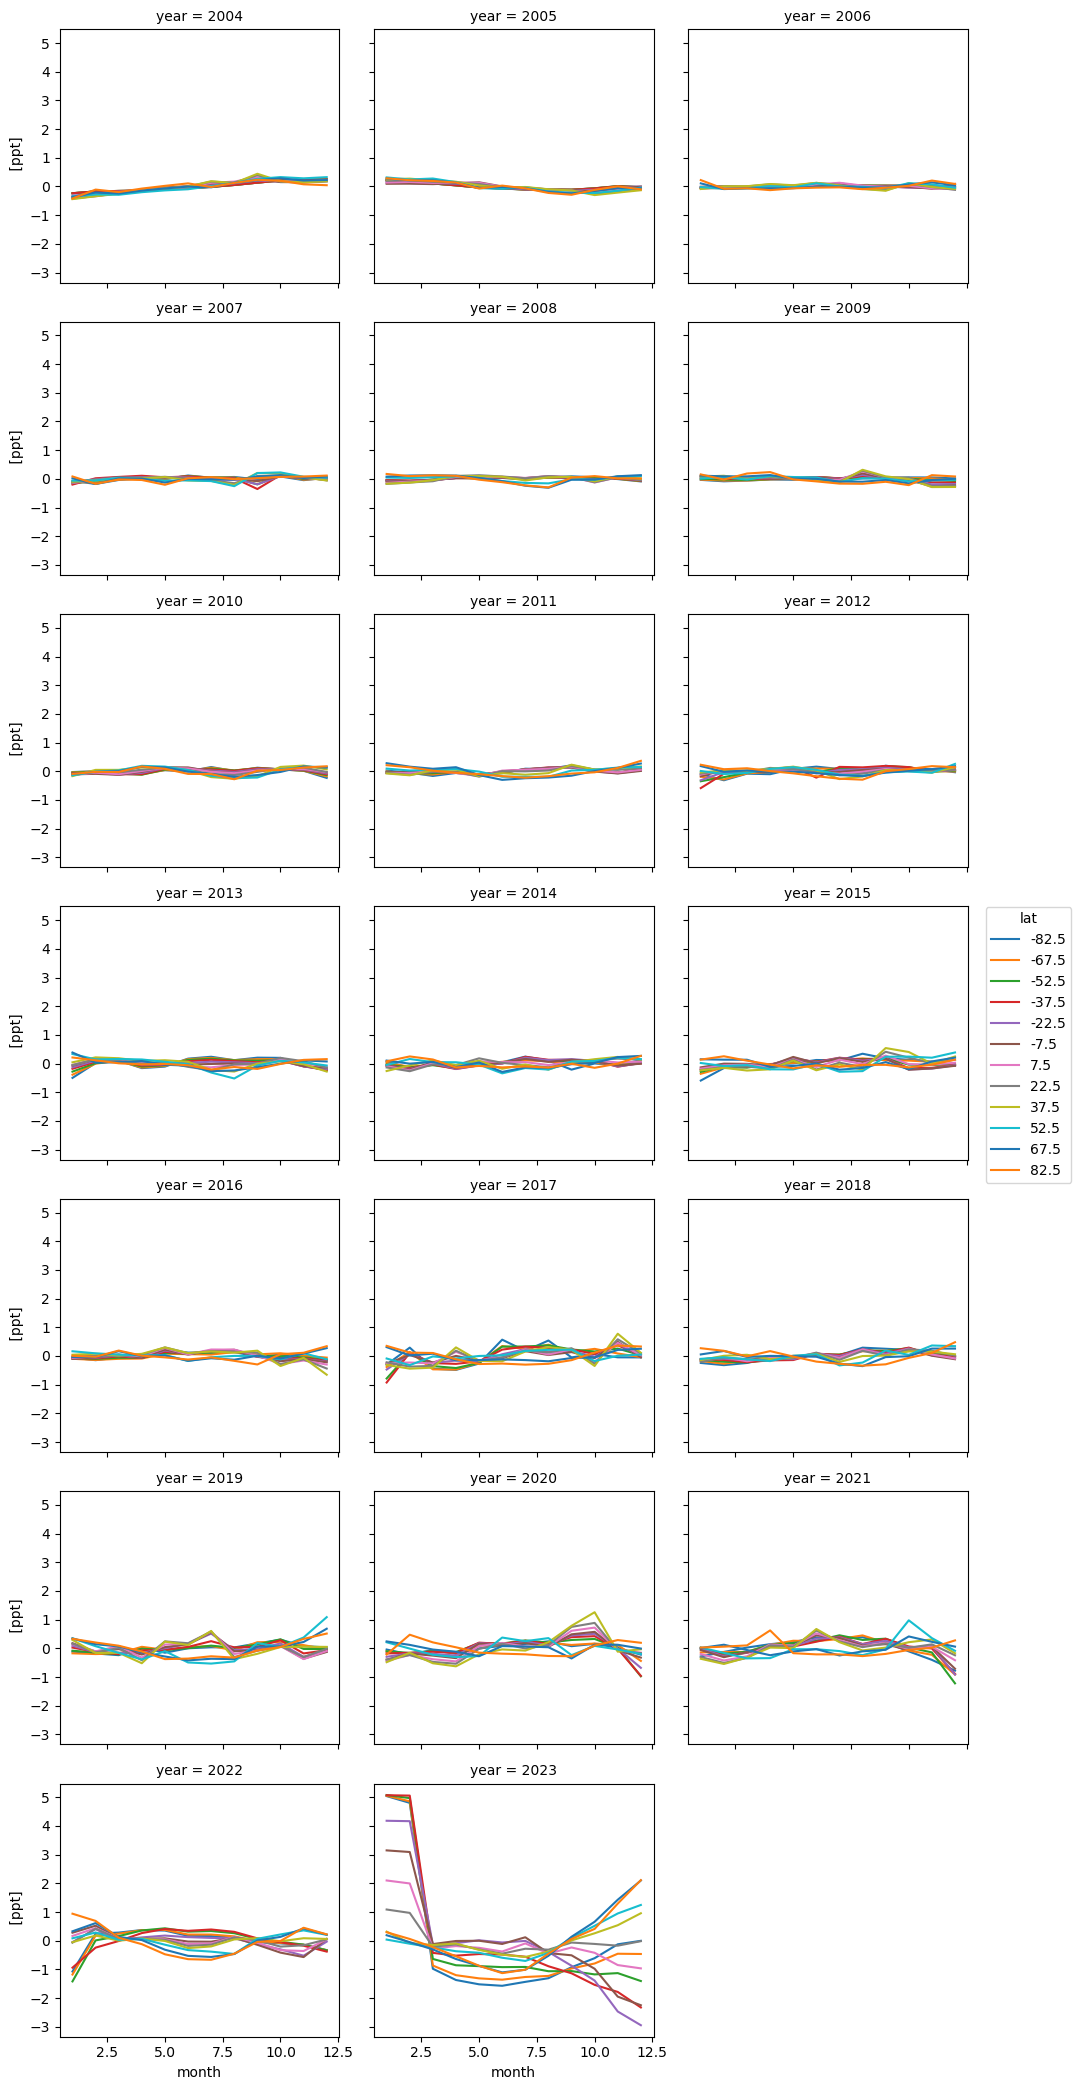

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

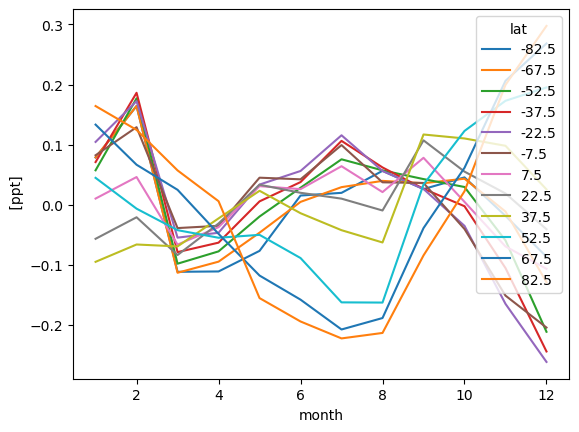

In [22]:
seasonality.plot.line(hue="lat")

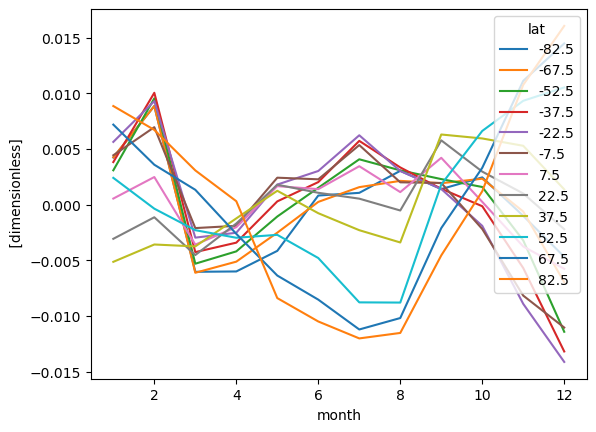

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[3.422211457854227 4.10065091192524 4.840455550572034 5.751660683867939 6.752002643648148 7.850790643376207 9.111747391581808 10.605857132831522 12.308726423312756 14.165832810938925 16.253876098576484 18.583636274756014 20.92351942404127 23.731455110188573 26.817392694040777 29.933733448895563 33.0086575407774 36.418253724746606 40.67257427231551 45.42209319517301]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.42692608156216194] [0.40348301613233933] [0.35207082516946275] [0.2855560430977262] [0.17235625678656974] [0.05494682337719199] [-0.07586703691274332] [-0.2022990203440026] [-0.3331063285985232] [-0.31962690750485545] [-0.2801120348147049] [-0.2800874597572463]]
Units,ppt
Magnitude,[[-1.3710821934573918] [-1.729205216399428] [-1.966729861719875] [-2.204364714704712] [-2.3244840523583514] [-2.4934894329922623] [-3.058023828414034] [-3.4372995944444047] [-3.873267058673456] [-4.378648182522422] [-4.821761407478649] [-5.081119510359022] [-5.423394783326795] [-6.028393271232784] [-6.411355330375513] [-7.0726817182927615] [-7.198164550511677] [-7.640671990820314] [-7.851633498096175] [-6.857523892240453]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[0.004235686885144414 0.0088674993299872 -0.006032477382806 -0.006000674395506246 -0.00415139784104089 0.0008196960100905768 0.0010615258507705675 0.003038504947450265 0.0014004341825305541 0.002449518522569785 -0.0010065738052665535 -0.004681778864726816] [0.004254571937866865 0.008861512999979747 -0.00611759895335878 -0.005120011227795877 -0.0025177466165565814 0.00024881995257712114 0.0015739979277579787 0.002136575549946662 0.0019285594216224531 0.002331783209867973 -0.0006179093639348882 -0.006962628368702699] [0.003085749898284788 0.009551551116312867 -0.00530331761413267 -0.004197213140445156 -0.0010659120748206284 0.0015193726449488376 0.00407555112625403 0.003081855492695437 0.002296843193867582 0.0015870781783383723 -0.003212274609137984 -0.01141943364780476] [0.0038255178124400858 0.010050159101472342 -0.004263819884464609 -0.003413067563779832 0.00029484337377006816 0.0020278658973061237 0.005730006937319928 0.003343839746612595 0.00142833664437571 -0.00013972656211408885 -0.005695290027374493 -0.0131888894998286] [0.005637325325343777 0.00929972985797536 -0.00296218611107599 -0.0025238826937822043 0.0018044450572632421 0.0030248609598186437 0.006232273928667435 0.0030250144689201843 0.0014082804194238692 -0.0019047231868134014 -0.008913366259066594 -0.014128018164325004] [0.004436208708478835 0.006960441931554816 -0.0021038059405051475 -0.0019026841139467147 0.002423096332303102 0.002277258137196646 0.005351120941750502 0.0020077444702930407 0.0019489914292914517 -0.0021868253964691274 -0.008170964810569174 -0.01104078273025911] [0.0005472919109418438 0.002481582069112586 -0.00358859516486119 -0.0020225632092827537 0.001663261162901096 0.0013936702084738322 0.003453637969387985 0.0011285794183069412 0.0042091563915211475 0.00025199665784371596 -0.0037556947280428512 -0.0057624574695736685] [-0.0030679668130254617 -0.0011329939727295322 -0.004525289941081146 -0.0016920930655119255 0.0017910312735336252 0.0010669460920640305 0.0005391818129830337 -0.000524143006050329 0.0057784716452701735 0.002968401352473585 0.0010050449872733385 -0.0022066955519379804] [-0.005136509227776165 -0.003578798347085579 -0.00374957849965722 -0.0012339440983969488 0.0012467721860730213 -0.0007680382165067252 -0.0022941899960665906 -0.0033966592460448 0.00630303473548626 0.005947481474066356 0.005288564105367532 0.001371786054047805] [0.0024078926584079154 -0.000360571825781789 -0.00229166344867189 -0.002973378642823129 -0.0027123190601919932 -0.004795160357784942 -0.008777383560138885 -0.008795895347822259 0.0018132279458643364 0.006622515468457222 0.00933132763470376 0.010531346560265876] [0.007190223899187025 0.003586654958512095 0.001334619934461919 -0.0026223976625905777 -0.006368081430498097 -0.008532871258343438 -0.011213465019220423 -0.010185296219410741 -0.0021057945002341534 0.0033096417600378576 0.011124874992491271 0.014481889796379039] [0.008859988957352965 0.006716946478147308 0.0030775507883178403 0.00030981884395535743 -0.008394020955073786 -0.010494803421688235 -0.012015697090402662 -0.011524601093376009 -0.004560948779562634 0.0012044730419478807 0.010764011579629482 0.016057275608076613]]
Units,dimensionless
